/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.
/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc
0


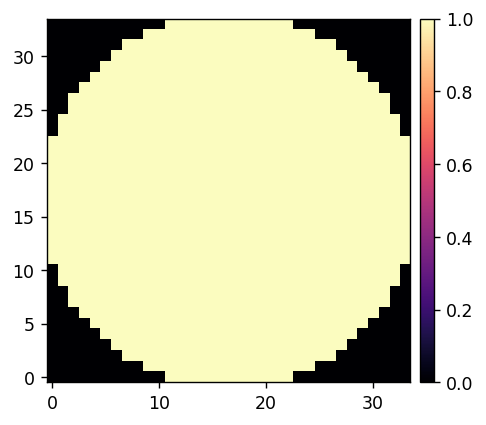

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils, telem, dm
from scoob_llowfsc import iefc_new as iefc
import scoob_llowfsc.scoob_interface as scoobi

from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

In [2]:
exp_path = data_path/f'exp-{today}'
iefc_data_path = data_path/f'exp-{today}'/'iefc'
telem.make_dir(exp_path)
telem.make_dir(iefc_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc' already exists.


In [7]:
scoobi.home_block(client0)

In [8]:
scoobi.move_block_out(client0)

In [3]:
reload(scoobi)
# camsci_channel = 'camsci'
camsci_channel = 'camlo'
dm_ho_channel = 'dm00disp03'

camsci_stream = ImageStream(camsci_channel)
dm_ho_stream = ImageStream(dm_ho_channel)

In [6]:
reload(scoobi)
# xc, yc = (4200, 2950)
xc, yc = (3900, 2575)
ncamsci = 256
scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel)
scoobi.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)
scoobi.set_cam_blacklevel(2, client0, cam_name=camsci_channel)


Set camlo ROI.
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


# Do the normalization

In [14]:
scoobi.move_psf(50, 0, client0)

In [19]:
scoobi.move_psf(0, -50, client0)

In [15]:
scoobi.move_psf(50, 0, client0)

In [62]:
scoobi.move_psf(0, -50, client0)

In [24]:
reload(scoobi)
scoobi.set_fib_atten(28, client)
scoobi.set_cam_exp_time(0.0005, client0, cam_name=camsci_channel)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)


Set the fiber attenuation to 28.0
Set the camlo exposure time to 5.00e-04s
Set the camlo gain setting to 120.0


0


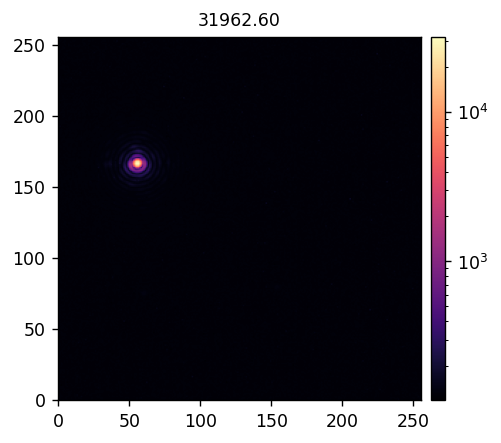

In [5]:
reload(scoobi)
ref_psf = scoobi.snap(camsci_stream, 200)
Iref = np.max(ref_psf)
utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])


In [9]:
reload(scoobi)
ref_psf_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
ref_psf_params.update({'Iref': Iref})
utils.save_pickle(iefc_data_path/f'{today}_ref_psf_params.pkl', ref_psf_params)

# ref_psf_params = utils.load_pickle(data_path/f'{today}_ref_psf_params.pkl')

print(ref_psf_params)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc/20250331_ref_psf_params.pkl
{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 28.0, 'Iref': np.float64(31962.6)}


# Move back onto the vortex and adjust exposure times

In [ ]:
scoobi.move_psf(-50, 0, client0)

In [20]:
scoobi.move_psf(0, 50, client0)

In [51]:
scoobi.move_psf(-1, 0, client0)

In [53]:
scoobi.move_psf(0, -1, client0)

In [ ]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
{'texp': 0.00499999988824129, 'gain': 120.0, 'atten': 0.0}


In [57]:
reload(scoobi)
scoobi.move_block_in(client0)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc/20250331_camsci_dark_frame_0.005000.pkl
0


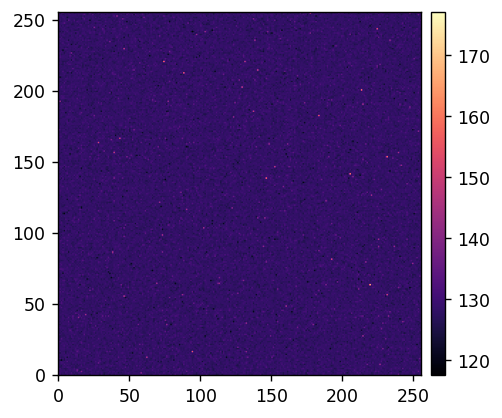

In [59]:
reload(scoobi)
dark_frame = scoobi.snap(camsci_stream, 500)
utils.save_pickle(iefc_data_path/f'{today}_camsci_dark_frame_{im_params["texp"]:.6f}.pkl', dark_frame)

utils.imshow([dark_frame])

In [60]:
reload(scoobi)
scoobi.move_block_out(client0)

# Use a waffle pattern to figure out the centering of the science camera images. 

0


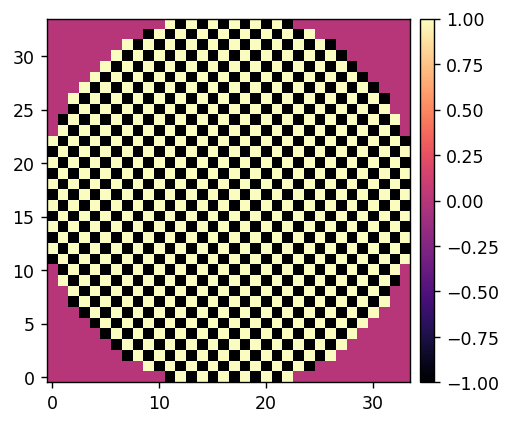

In [63]:
reload(dm)
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

0


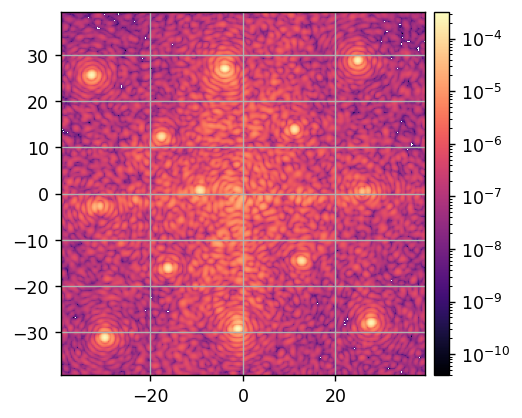

In [66]:
reload(scoobi)
scoobi.set_dm(dm_ho_stream, 10e-9 * waffle_command)
waffle_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_psf_params)
utils.imshow([waffle_im], norms=[LogNorm()], cmaps=['magma'], grids=[1], pxscls=[camsci_pxscl_lamDc])

Centroids:
 [[ 74.86462078  74.74503473]
 [ 70.22832865 167.30333012]
 [163.74489871 172.25566623]
 [168.68168325  79.79119322]
 [ 74.86462078  74.74503473]]
1


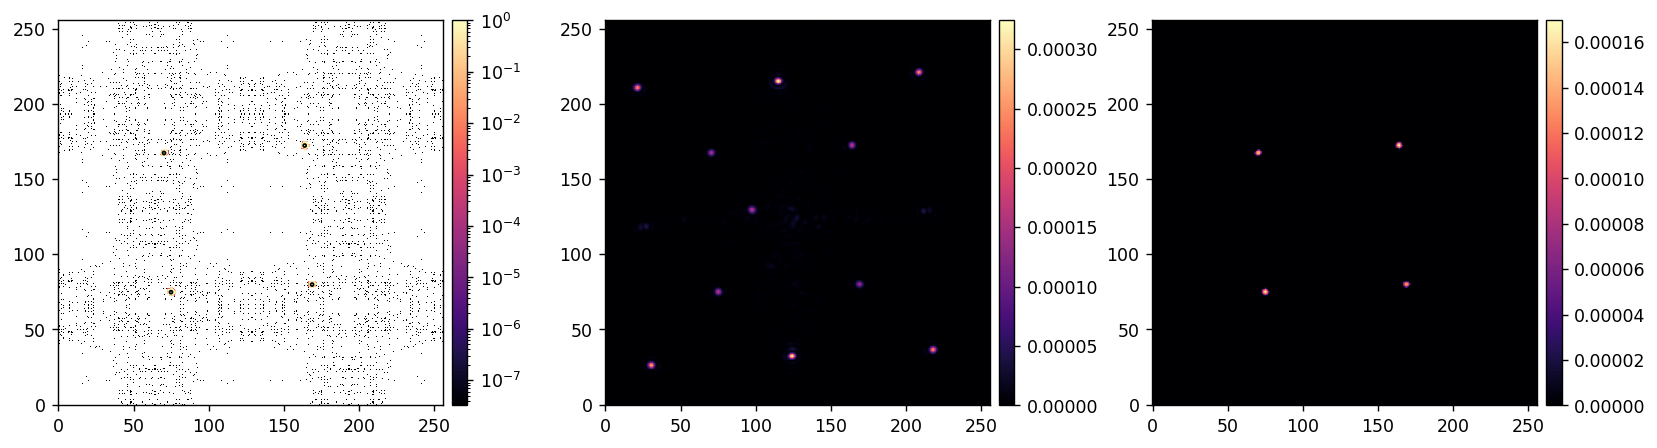

Angle:  86.99151360005212
Measured center in X:  119.3956273811497
Measured center in Y:  123.60004144095711
Required shift in X:  9.0
Required shift in Y:  4.0


In [72]:
reload(utils)

xshift, yshift, angle = utils.measure_waffle_center_and_angle(
    xp.array(waffle_im), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-5, 
    r_thresh_min=16,
    r_thresh_max=25,
)

# Create the mask defining the dark hole region. 

1022
0


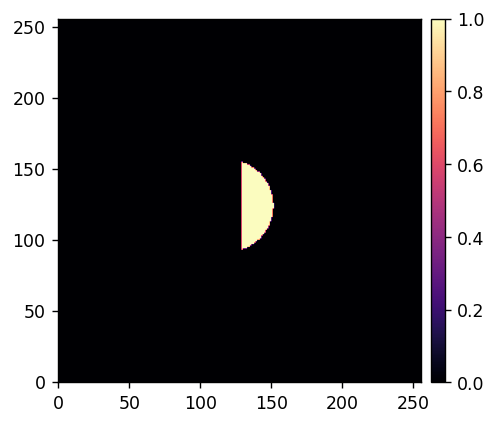

In [80]:
reload(utils)
ncamsci = 256
iwa = 3
owa = 10
rotation = 0
control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
))
print(control_mask.sum())
utils.imshow([control_mask])

In [76]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, cam_name=camsci_channel)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
{'texp': 0.00499999988824129, 'gain': 120.0, 'atten': 0.0}


2.2310930320273484e-06
1


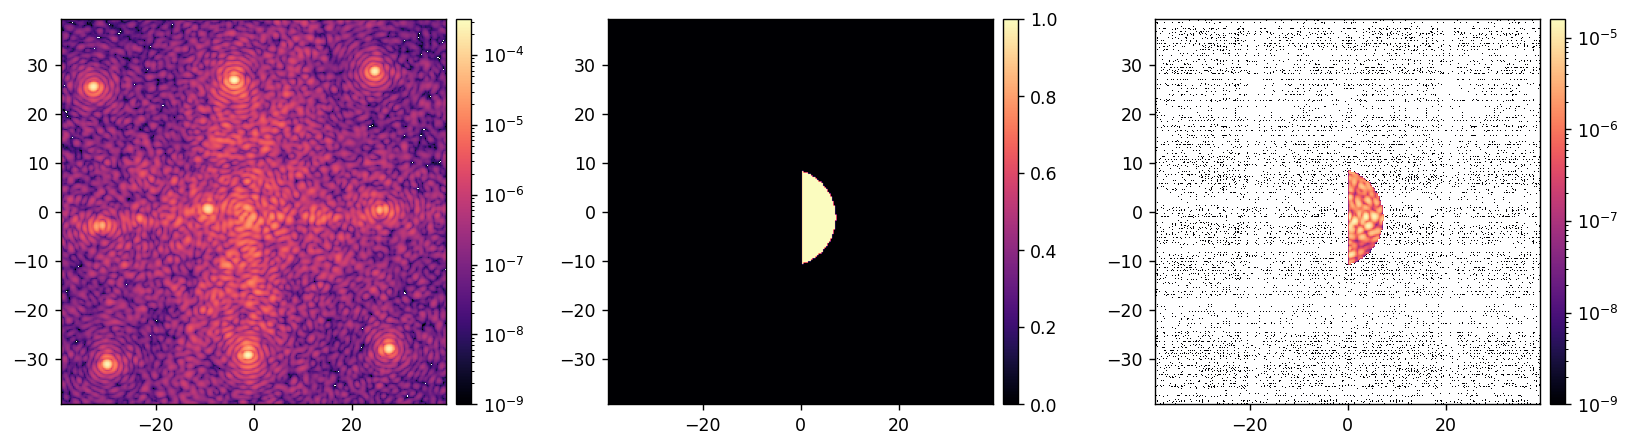

In [81]:
scoobi.zero_dm(dm_ho_stream)

ref_coro_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_psf_params)
print(np.mean(ref_coro_im[control_mask]))
utils.imshow(
    [ref_coro_im, control_mask, control_mask * ref_coro_im],
    norms=[LogNorm(1e-9), None, LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
)

# Create the probe commands and the calibration modes to be used. 

1


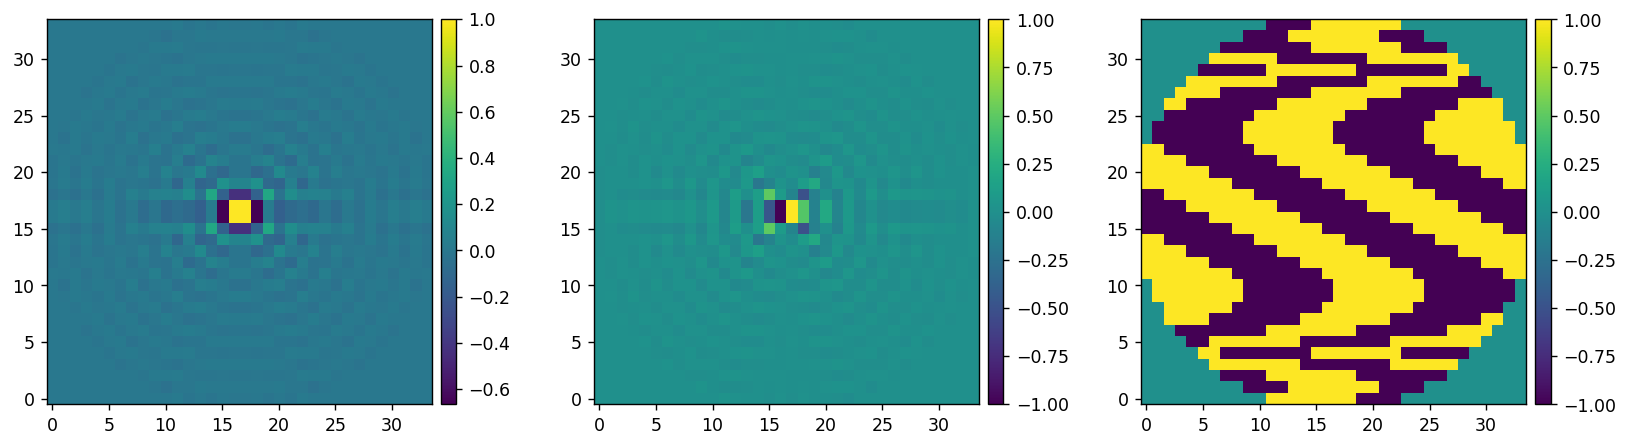

In [ ]:
reload(utils)
reload(dm)
probe_iwa = 2
probe_owa = 15

fourier_probes = ensure_np_array(dm.create_fourier_probes(
    xp.array(dm_mask), 
    ncamsci,
    camsci_pxscl_lamDc,
    probe_iwa,
    probe_owa,
    # edge=probe_iwa,
    fourier_sampling=0.75, 
    # rotation=90,
    nprobes=2,
    # plot=True,
    use_weighting=True,
))

calib_modes = ensure_np_array( dm.create_hadamard_modes(xp.array(dm_mask)) ) 
modal_matrix = calib_modes.reshape(calib_modes.shape[0], -1).T

utils.imshow([fourier_probes[0], fourier_probes[1], calib_modes[8]], cmaps=3*['viridis'])

# Test the probes.

1


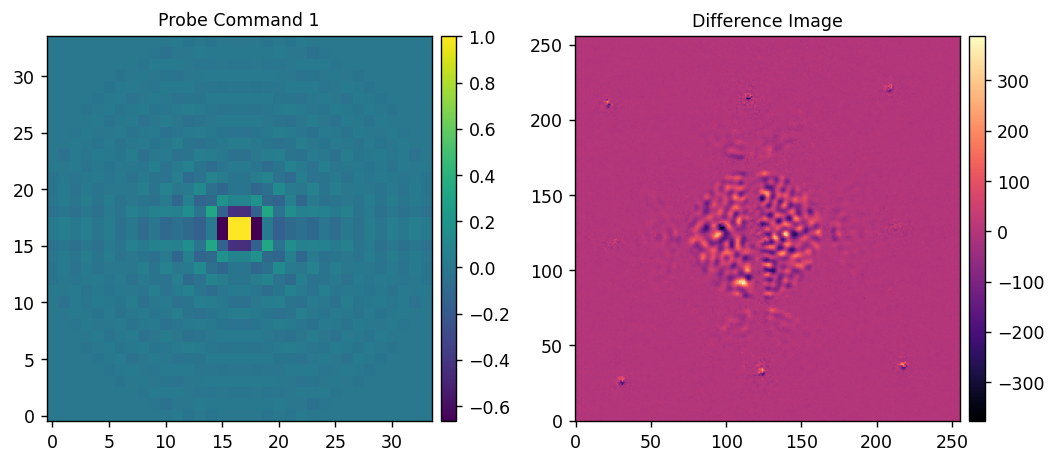

1


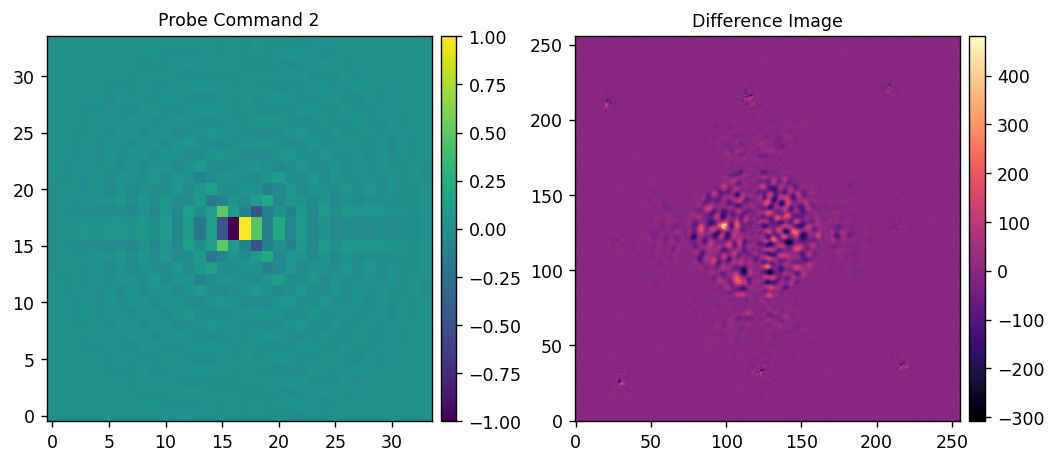

1


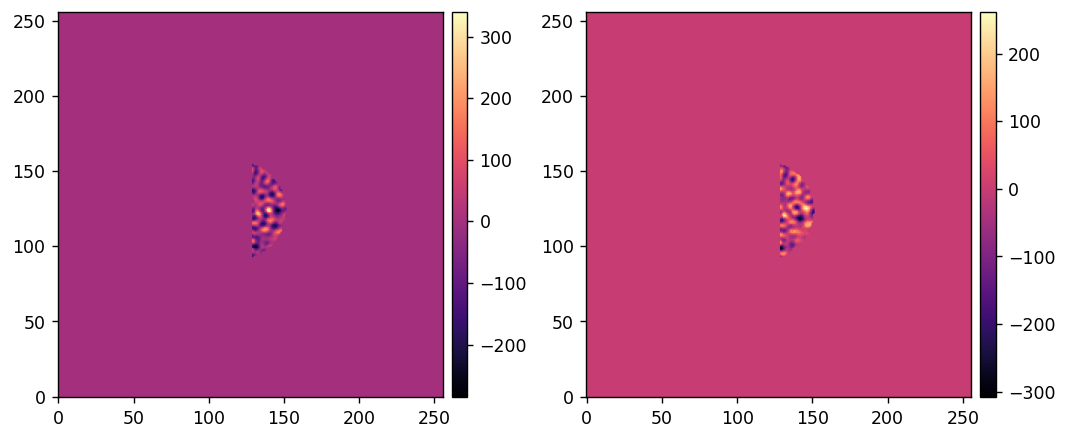

In [90]:
reload(iefc)
scoobi.zero_dm(dm_ho_stream)

diff_ims = iefc.take_measurement(
    camsci_stream, 
    dm_ho_stream, 
    im_params,
    ref_psf_params,
    fourier_probes,
    probe_amplitude=3e-9,
    NFRAMES=25,
    plot=True, 
)
diff_ims *= control_mask
utils.imshow([diff_ims[0], diff_ims[1]])

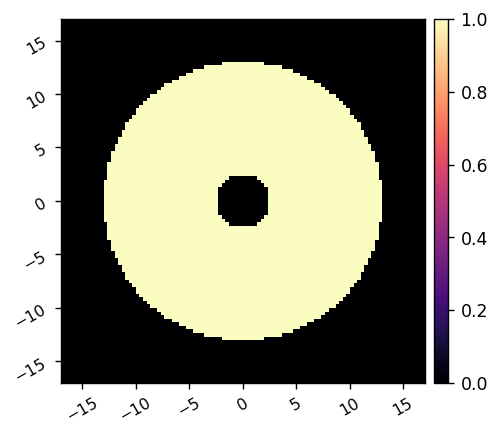

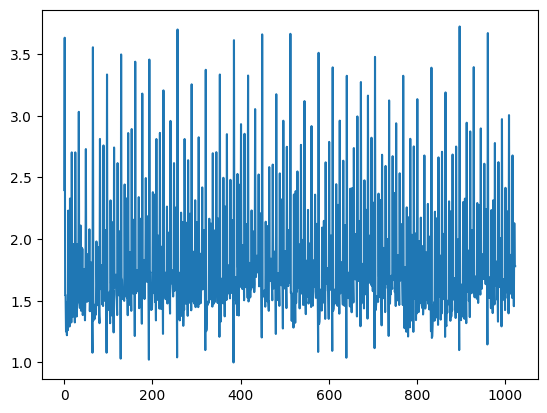

In [87]:
reload(iefc)
scale_factors = iefc.compute_hadamard_scale_factors(xp.array(calib_modes), scale_exp=1/5, scale_thresh=4, oversamp=3, plot=True)

Calibrating iEFC...
	Calibrated mode 1024/1024 in 1211.291s
Calibration complete.
1


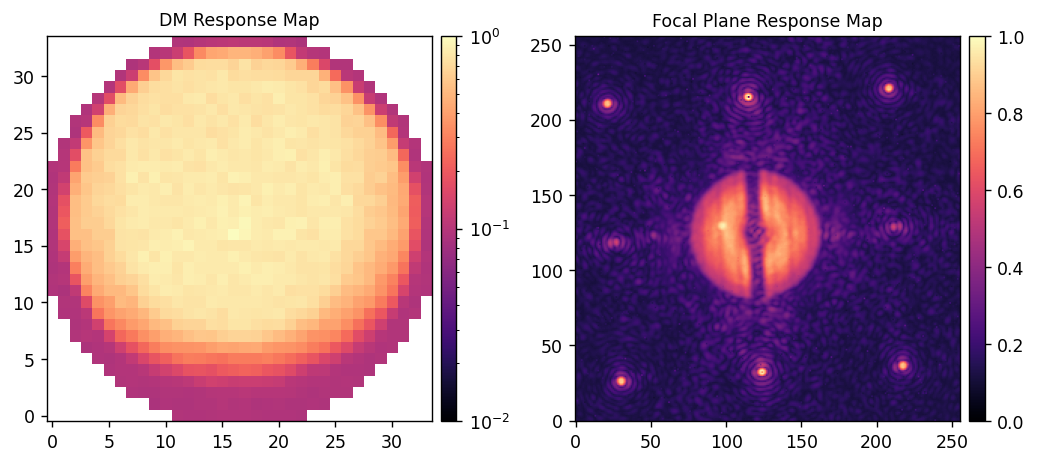

In [95]:
reload(iefc)
scoobi.zero_dm(dm_ho_stream)

probe_amp = 2.5e-9
calib_amp = 2.5e-9

NFRAMES = 20

response_matrix, response_cube = iefc.calibrate(
    camsci_stream, 
    dm_ho_stream, 
    control_mask, 
    probe_amp, 
    fourier_probes, 
    calib_amp, 
    calib_modes[:],
    im_params,
    ref_psf_params,
    NFRAMES=NFRAMES,
    delay=0.01,
    scale_factors=scale_factors, 
    plot_responses=True, 
)

In [96]:
iefc_calib_data = {
    'response_matrix':response_matrix,
    'response_cube':response_cube,
    'control_mask':control_mask,
    'NFRAMES':NFRAMES,
    'probe_amp':probe_amp,
    'probe_modes':fourier_probes,
    'calib_amp':calib_amp,
    'scale_factors':scale_factors,
}
utils.save_pickle(iefc_data_path/f'{today}_iefc_calib_lr.pkl', iefc_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc/20250331_iefc_calib_lr.pkl


In [ ]:
# calib_data = utils.load_pickle(iefc_data_path/f'{today}_iefc_calib_lr.pkl')
# response_cube = response_cube['response_cube']
# response_matrix = response_cube[:, :, control_mask.ravel()].reshape(1024, -1).T

In [103]:
scoobi.zero_dm(dm_ho_stream)

In [101]:
reload(utils)
cm25 = utils.beta_reg(response_matrix, -2.5, return_np=1)
cm50 = utils.beta_reg(response_matrix, -5, return_np=1)
cm60 = utils.beta_reg(response_matrix, -6, return_np=1)


In [ ]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, camsci_name=camsci_channel)
scoobi.set_cam_gain(120, client0, camsci_name=camsci_channel)

im_params = scoobi.get_im_params(client0, client)
print(im_params)

2.183261008220137e-06
1


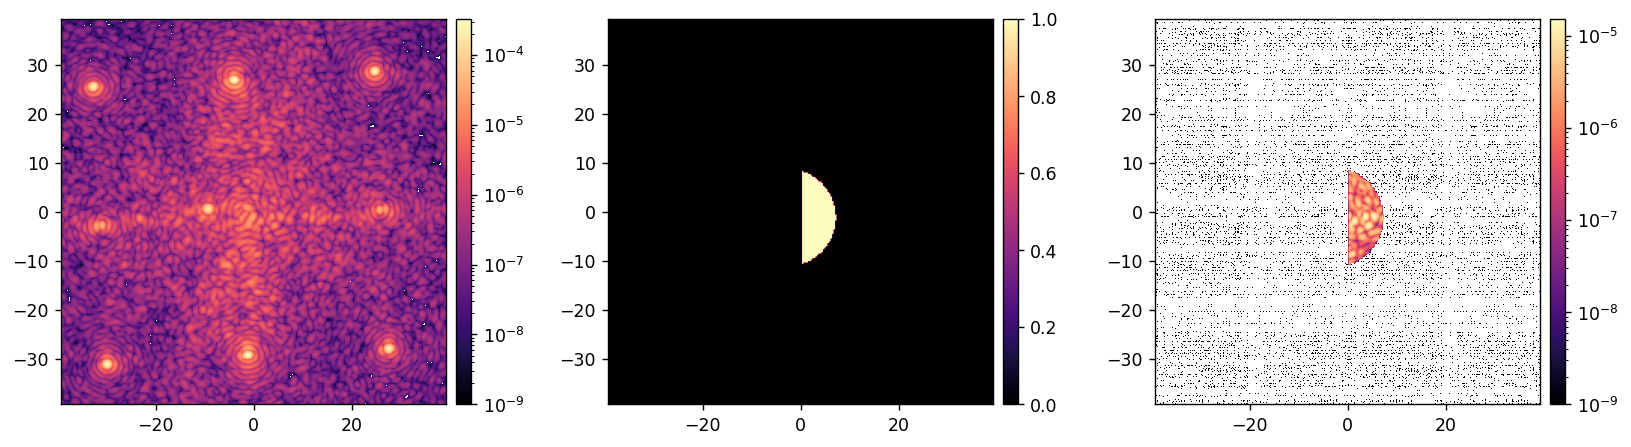

In [104]:

ref_coro_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_psf_params)
ref_contrast = np.mean(ref_coro_im[control_mask])
print(ref_contrast)
utils.imshow(
    [ref_coro_im, control_mask, control_mask * ref_coro_im],
    norms=[LogNorm(1e-9), None, LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
)

In [105]:
reload(scoobi)
scoobi.zero_dm(dm_ho_stream)

iefc_data = {
    'images':[ref_coro_im],
    'contrasts':[ref_contrast],
    'commands':[],
    'del_commands':[],
    'pixelscale':camsci_pxscl_lamDc,
    'control_mask':control_mask, 
    'probes':fourier_probes,
}

Running iEFC...
	Running iteration 28 / 30
1


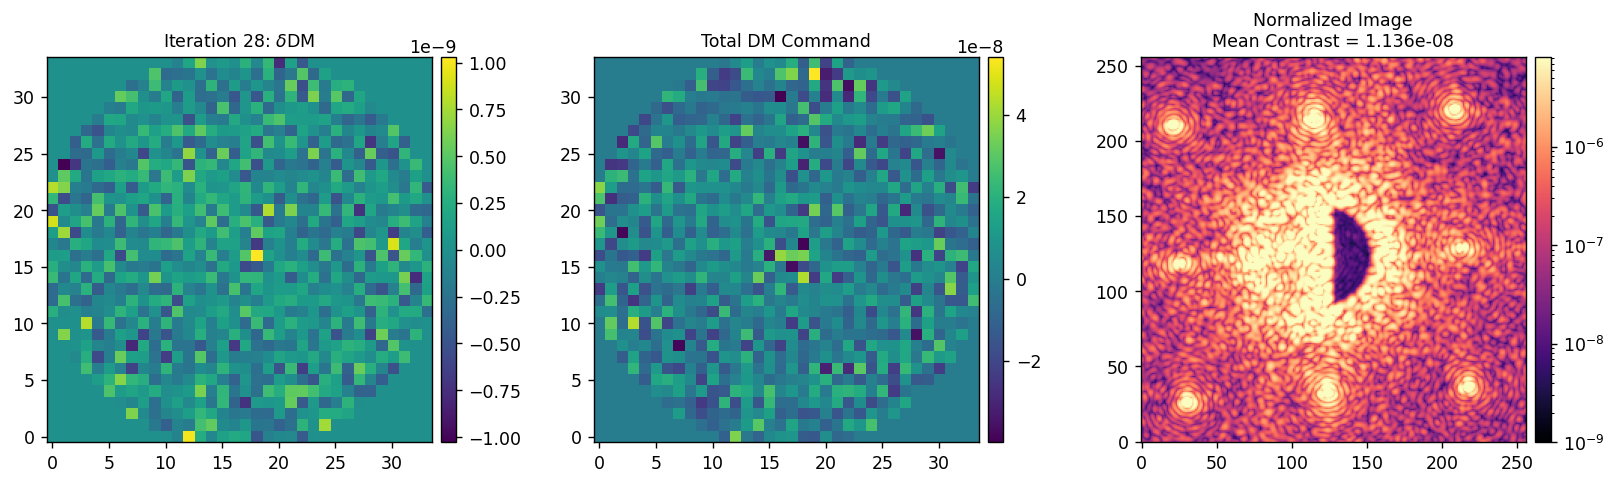

	Running iteration 29 / 30
1


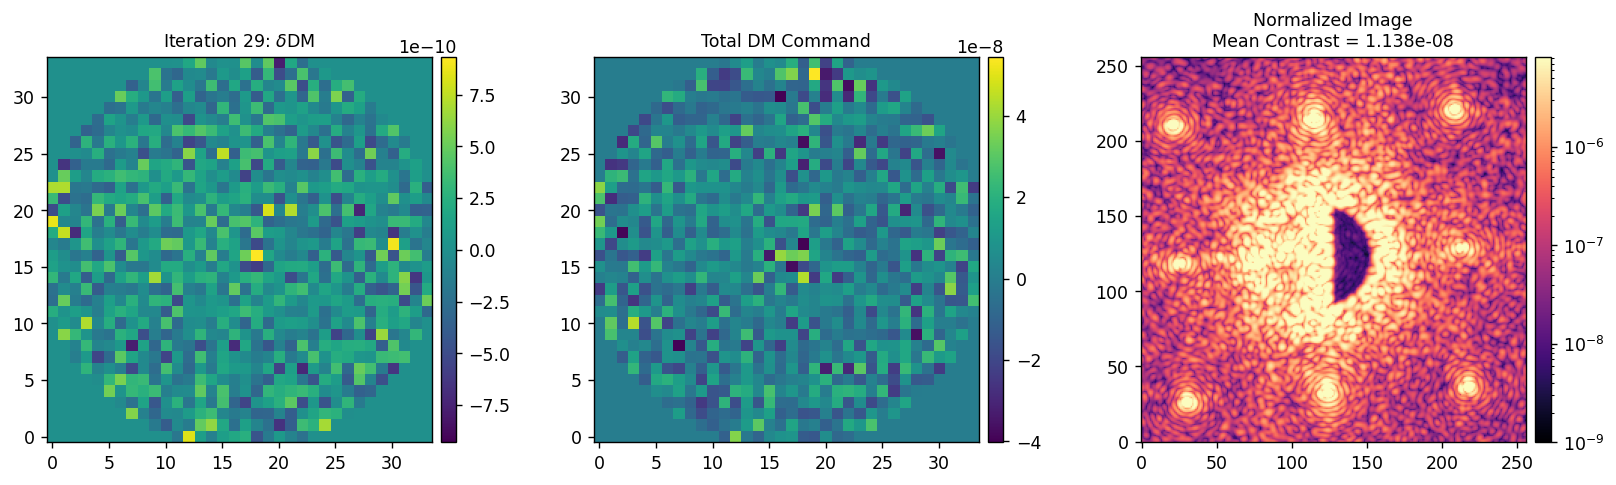

	Running iteration 30 / 30
1


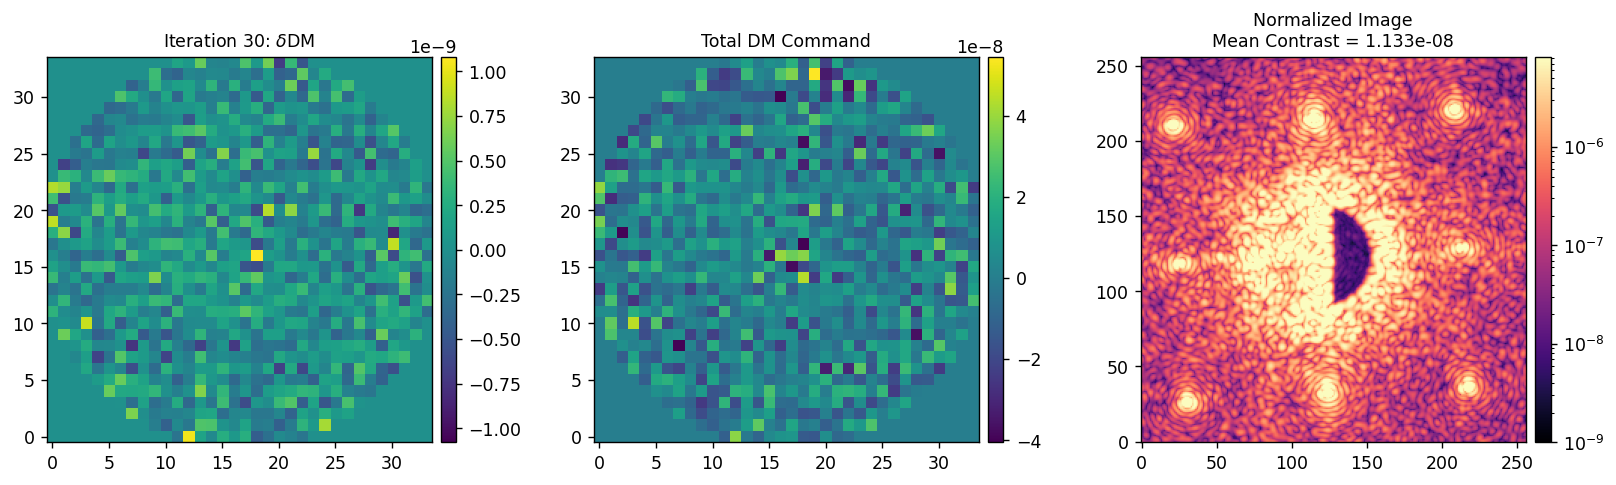

Completed 3 in 47.581s.


In [129]:
reload(utils)
reload(iefc)

probe_amp = 5e-9
probe_amp = 4e-9
probe_amp = 3e-9
probe_amp = 2.5e-9
# probe_amp = 2e-9
# probe_amp = 1.5e-9
probe_amp = 1e-9
# probe_amp = 0.75e-9
# probe_amp = 0.5e-9
# probe_amp = 0.25e-9

NFRAMES = 15

iefc_data = iefc.run(
    iefc_data, 
    camsci_stream,
    dm_ho_stream,
    cm25,
    # cm50,
    # cm60,
    probe_amp, 
    fourier_probes, 
    modal_matrix,
    control_mask,
    im_params,
    ref_psf_params, 
    dark_frame, 
    NFRAMES=NFRAMES, 
    delay=0.01,
    num_iterations=3,
    gain=0.75, 
    leakage=0.0,
    plot_current=True,
    plot_all=True,
    vmin=1e-9,
)

In [130]:
# utils.save_pickle(iefc_data_path/f'{today}_iefc_run_bottom.pkl', iefc_data)
utils.save_pickle(iefc_data_path/f'{today}_iefc_run_right.pkl', iefc_data)


Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc/20250331_iefc_run_right.pkl


In [110]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.2, client0, cam_name=camsci_channel)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 2.00e-01s
Set the camlo gain setting to 120.0
{'texp': 0.200000002980232, 'gain': 120.0, 'atten': 0.0}


In [111]:
reload(scoobi)
scoobi.move_block_in(client0)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250331/iefc/20250331_camsci_dark_frame_0.200000.pkl
0


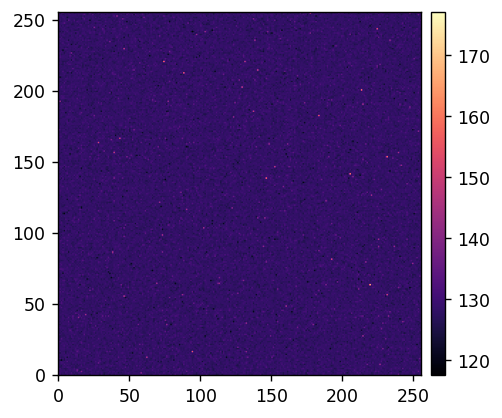

In [112]:
scoobi.snap(camsci_stream, 200)
utils.save_pickle(iefc_data_path/f'{today}_camsci_dark_frame_{im_params["texp"]:.6f}.pkl', dark_frame)

utils.imshow([dark_frame])

In [113]:
reload(scoobi)
scoobi.move_block_out(client0)

1.1500865535137698e-08
1


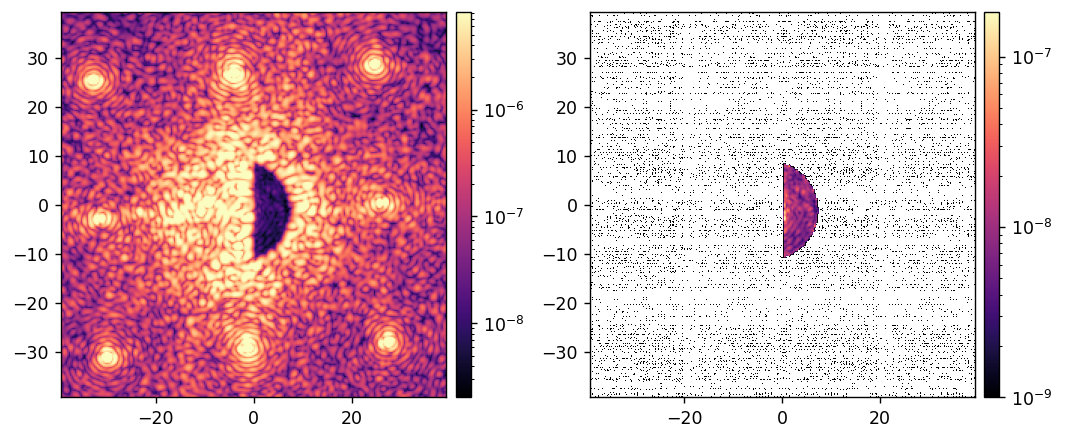

In [124]:
coro_im = scoobi.snap(camsci_stream, 50, dark_frame, im_params, ref_psf_params)
contrast = np.mean(coro_im[control_mask])

print(contrast)
utils.imshow(
    [coro_im, control_mask * coro_im],
    norms=[LogNorm(), LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
)

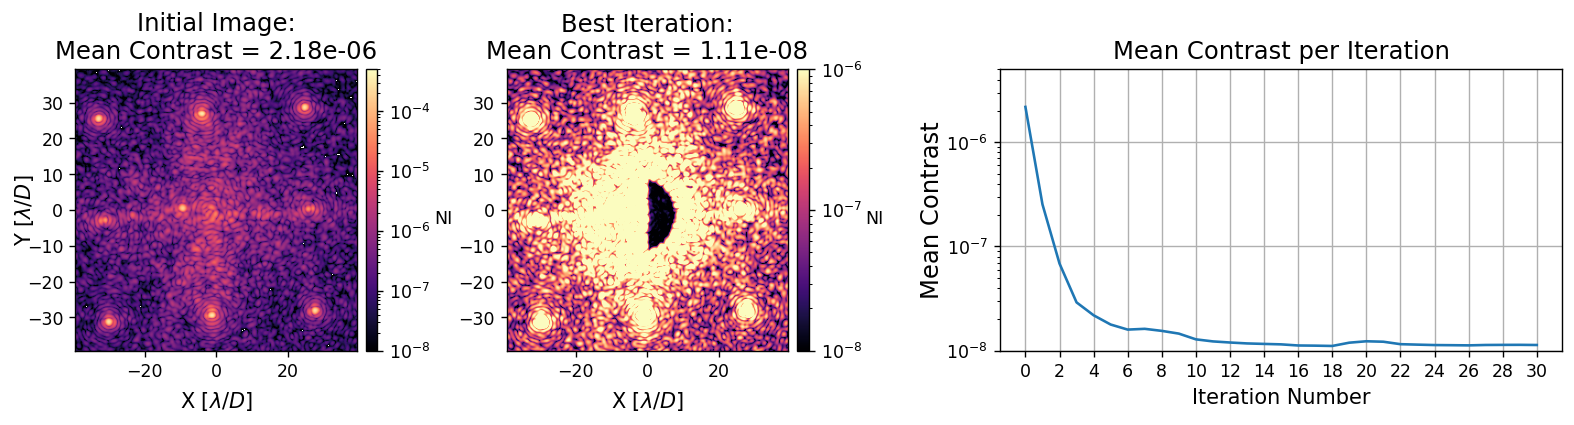

In [131]:
reload(iefc)

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

In [167]:
old_data = utils.load_pickle(iefc_data_path/f'{today}_iefc_run_bottom.pkl')

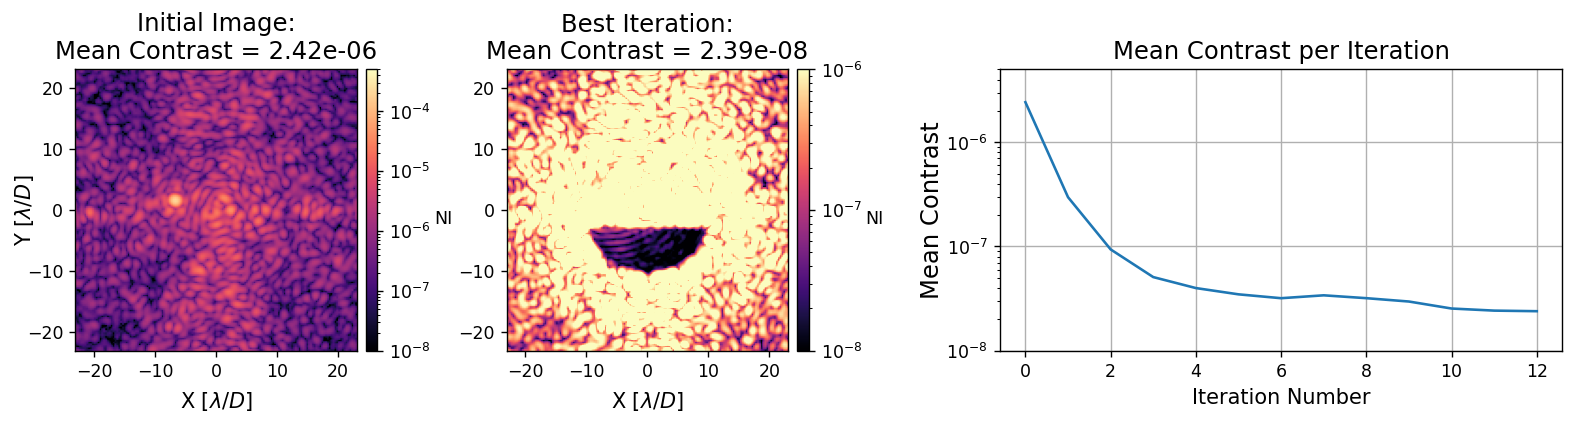

In [168]:
reload(iefc)

iefc.plot_data_with_ref(
    old_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

In [ ]:
scoobi.set_camsci_exp_time(0.2, client0, camsci_name=camsci_channel)
scoobi.zero_dm()

Set the CAMSCI exposure time to 5.00e-03s


# Make plot for LLOWFSC offset accuracy

In [ ]:
camlo_stream = ImageStream('camnsv')
camlo_ref_stream = ImageStream('camlo_ref_0')
camlo_ref_offset_stream = ImageStream('camlo_ref_offset')
camlo_ref_im0 = camlo_ref_stream.grab_latest()

In [ ]:
final_iefc_command = data['commands'][-1]
NCAMLO = 30
I.set_dm(final_iefc_command)
dark_hole_im = I.snap_camsci()
real_camlo_ref_im = camlo_stream.grab_many(NCAMLO)/NCAMLO
real_offset = real_camlo_ref_im - camlo_ref_im0
predicted_offset = camlo_ref_offset_stream.grab_latest()
offset_error = real_offset - predicted_offset

imshow3(
    real_offset,
    predicted_offset,
    offset_error, 
    grid=1,
)

In [ ]:
# offset_response_matrix = utils.load_pickle('exp-data/llowfsc_hsvd_calibration.pkl')
zer_calib_data = utils.load_pickle('exp-data/llowfsc_zernike_calibration.pkl')
zer_calib_modes = zer_calib_data['dm_modes']
control_matrix = zer_calib_data['control_matrix']
llowfsc_mask = zer_calib_data['llowfsc_mask']
offset_error_coeff = control_matrix.dot(offset_error[llowfsc_mask])
offset_error_opd = xp.sum( offset_error_coeff[:, None, None] * zer_calib_modes, axis=0)

I.add_dm(offset_error_opd)
dark_hole_im_with_lo_error = I.snap_camsci()

imshow2(
    offset_error_opd,
    dark_hole_im_with_lo_error,
    lognorm2=1,
    vmin2=1e-9,
)